# 05 — Churn Models: Random Forest, XGBoost, Calibration, Error Analysis

Continues from `04_churn_baseline.ipynb`. Trains the ensemble/boosting candidates, selects the champion on the **validation** snapshot only, then reports final numbers on the held-out test snapshot exactly once.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
from data import config
from churn.dataset import build_training_pool, build_snapshot, feature_columns, LABEL_COLUMN

ROOT = '../data/raw'
customers = pd.read_parquet(f'{ROOT}/customers.parquet')
orders = pd.read_parquet(f'{ROOT}/orders.parquet')
interactions = pd.read_parquet(f'{ROOT}/interactions.parquet')
support = pd.read_parquet(f'{ROOT}/support.parquet')
products = pd.read_parquet(f'{ROOT}/products.parquet')

train_cutoffs = [pd.Timestamp(d) for d in
                 ['2024-09-30', '2024-12-31', '2025-03-31', '2025-06-30', '2025-09-30']]
pool = build_training_pool(customers, orders, interactions, support, products, train_cutoffs)

val_cutoff = train_cutoffs[-1]
train_pool = pool[pool['snapshot_cutoff'] != val_cutoff]
val_pool = pool[pool['snapshot_cutoff'] == val_cutoff]

test_cutoff = pd.Timestamp(config.OBSERVATION_CUTOFF)
test_pool = build_snapshot(customers, orders, interactions, support, products, test_cutoff)

feat_cols = feature_columns(pool)
X_train, y_train = train_pool[feat_cols], train_pool[LABEL_COLUMN]
X_val, y_val = val_pool[feat_cols], val_pool[LABEL_COLUMN]
X_test, y_test = test_pool[feat_cols], test_pool[LABEL_COLUMN]

print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)
print(f'churn rate -- train: {y_train.mean():.1%}  val: {y_val.mean():.1%}  test: {y_test.mean():.1%}')

train: (19974, 27) val: (5508, 27) test: (5097, 27)
churn rate -- train: 24.0%  val: 28.1%  test: 28.6%


In [2]:
from churn.train import (train_baseline, train_logistic_regression, train_random_forest,
                          train_xgboost, predict_churn_probability)
from churn.evaluate import evaluate_churn_model, calibration_table, segment_performance

models = {
    'baseline': train_baseline(X_train, y_train),
    'logistic': train_logistic_regression(X_train, y_train),
    'random_forest': train_random_forest(X_train, y_train),
    'xgboost': train_xgboost(X_train, y_train),
}
print('trained:', list(models))

trained: ['baseline', 'logistic', 'random_forest', 'xgboost']


## Model selection on the validation snapshot (test set untouched so far)

In [3]:
val_results = {name: evaluate_churn_model(y_val, predict_churn_probability(m, X_val))
               for name, m in models.items()}
pd.DataFrame(val_results).T[['roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'brier_score', 'lift_at_10pct']].round(3)

,roc_auc,pr_auc,precision,recall,f1,brier_score,lift_at_10pct
baseline,0.500,0.281,0.000,0.000,0.000,0.204,0.965
logistic,0.855,0.698,0.530,0.829,0.646,0.174,2.857
random_forest,0.861,0.723,0.556,0.799,0.656,0.155,3.019
xgboost,0.861,0.726,0.548,0.809,0.653,0.158,3.025


In [4]:
best_name = max(['logistic', 'random_forest', 'xgboost'], key=lambda n: val_results[n]['pr_auc'])
print('champion (by validation PR-AUC):', best_name)

champion (by validation PR-AUC): xgboost


## Final held-out test metrics — reported once, for every model

Reporting all four (not just the champion) on the true test set is deliberate: it shows the validation-based selection wasn't cherry-picked after peeking at test performance.

In [5]:
test_results = {name: evaluate_churn_model(y_test, predict_churn_probability(m, X_test))
                for name, m in models.items()}
pd.DataFrame(test_results).T[['roc_auc', 'pr_auc', 'precision', 'recall', 'f1', 'brier_score', 'lift_at_10pct']].round(3)

,roc_auc,pr_auc,precision,recall,f1,brier_score,lift_at_10pct
baseline,0.500,0.286,0.000,0.000,0.000,0.206,1.030
logistic,0.852,0.710,0.511,0.843,0.636,0.184,2.958
random_forest,0.859,0.736,0.558,0.799,0.657,0.156,3.061
xgboost,0.861,0.735,0.550,0.812,0.656,0.159,3.013


## Calibration (champion model, test set)

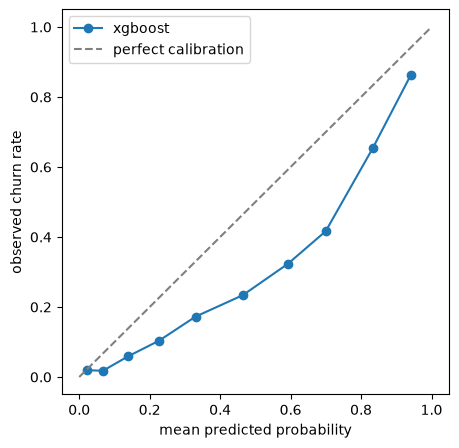

,n,mean_predicted,observed_rate
bin,,,
0,510,0.021581,0.019608
1,510,0.067116,0.017647
2,509,0.138496,0.058939
3,510,0.226871,0.103922
4,510,0.330274,0.172549
5,509,0.464399,0.233792
6,510,0.592539,0.323529
7,509,0.699648,0.416503
8,510,0.832809,0.652941


In [6]:
champion = models[best_name]
champion_proba_test = predict_churn_probability(champion, X_test)
cal = calibration_table(y_test, champion_proba_test)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(cal['mean_predicted'], cal['observed_rate'], marker='o', label=best_name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='perfect calibration')
ax.set_xlabel('mean predicted probability')
ax.set_ylabel('observed churn rate')
ax.legend()
plt.show()
cal

## Error analysis: performance by segment (guide 11.1)

In [7]:
print('by plan:')
display(segment_performance(y_test, champion_proba_test, test_pool['plan']))
print('\nby acquisition channel:')
display(segment_performance(y_test, champion_proba_test, test_pool['acquisition_channel']))

by plan:


,segment,n,actual_churn_rate,predicted_positive_rate,recall,precision
2,silver,2029,0.221291,0.26417,0.699332,0.585821
0,bronze,2027,0.448446,0.75037,0.880088,0.525970
1,gold,1041,0.097022,0.09414,0.702970,0.724490



by acquisition channel:


,segment,n,actual_churn_rate,predicted_positive_rate,recall,precision
2,organic,1483,0.294673,0.443695,0.835240,0.554711
3,paid_search,1173,0.255754,0.352941,0.796667,0.577295
5,social,872,0.326835,0.514908,0.814035,0.516704
4,referral,565,0.235398,0.306195,0.729323,0.560694
0,affiliate,517,0.326886,0.495164,0.834320,0.550781
1,email,487,0.277207,0.420945,0.822222,0.541463


## Feature importance (champion model)

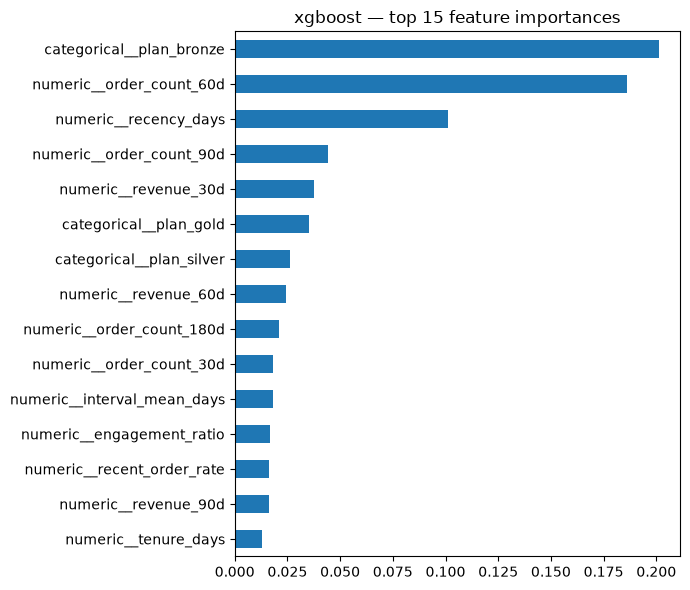

In [8]:
pre = champion.named_steps['preprocess']
feature_names = pre.get_feature_names_out()
importances = champion.named_steps['model'].feature_importances_
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
imp.sort_values().plot(kind='barh', figsize=(7, 6), title=f'{best_name} — top 15 feature importances')
plt.tight_layout()
plt.show()

## Takeaways

See `docs/model_card.md` for the full write-up (numbers pulled directly from this notebook's execution, not restated by hand).